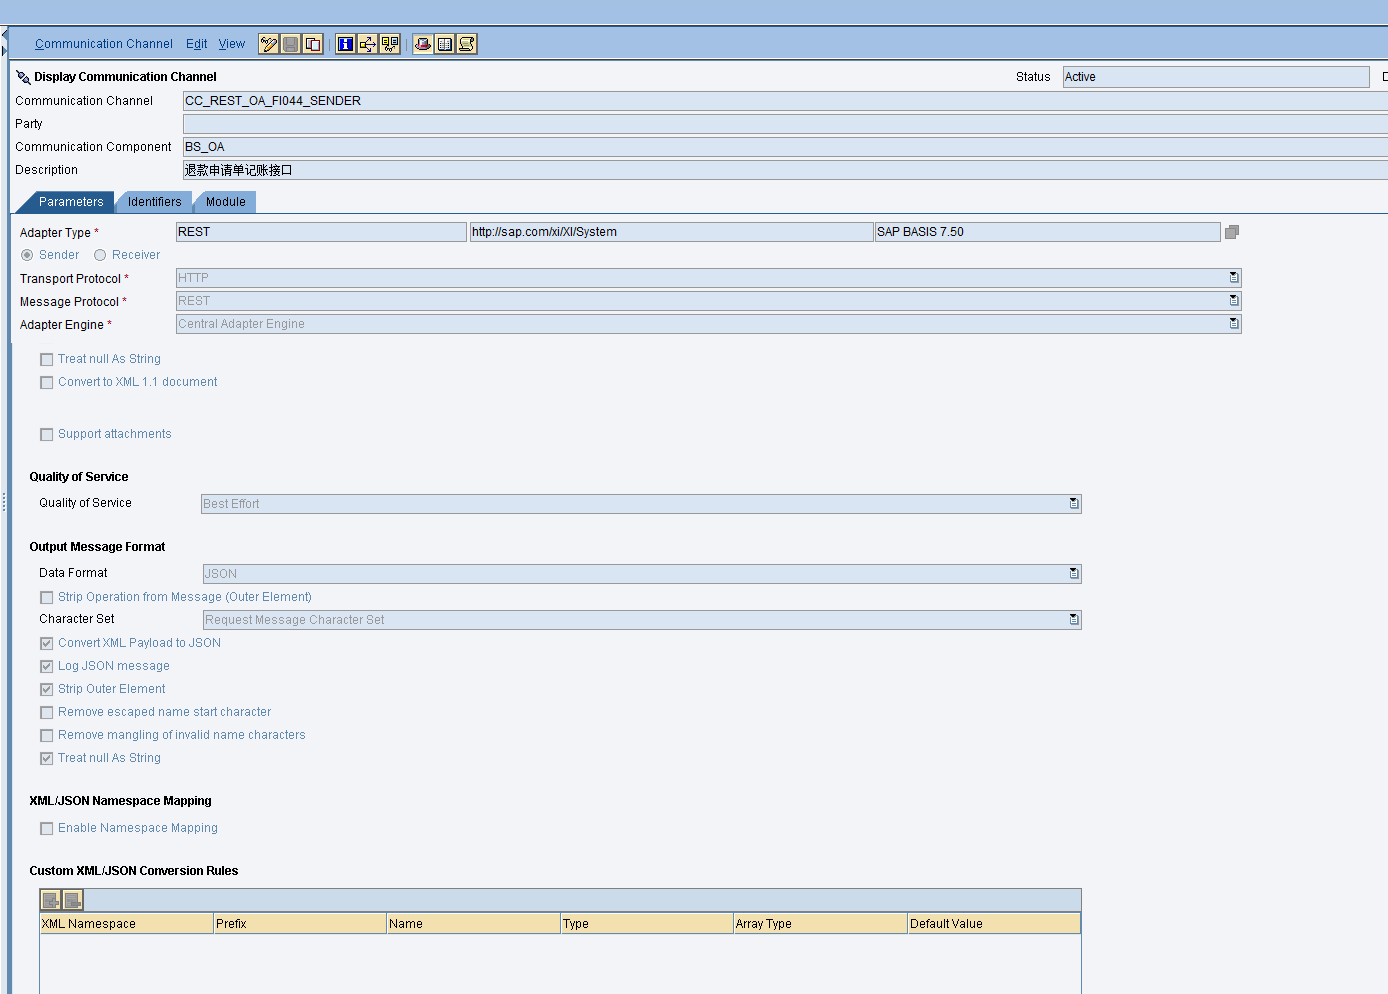

理解了。既然你是要做完整的配置梳理，为了让你彻底弄明白这个 **REST 适配器（发送方通道）** 的逻辑，我将这个通道的参数按功能模块拆解为一份“完整清单”。

这个通道的功能是：**将外部发送的 JSON 转换为 SAP 内部的 XML（请求），并将 SAP 返回的 XML 转换为 JSON（响应）。**

---

### 一、 常规参数 (General Settings)

* **Adapter Type (REST)**: 指定使用 REST 协议，这是目前主流的 Web 接口协议。
* **Transport Protocol (HTTP)**: 基于底层的 HTTP 传输。
* **Message Protocol (REST)**: 适配器通信协议。
* **Adapter Engine (Central Adapter Engine)**: 使用 PI 系统的核心引擎处理。

---

### 二、 输入消息格式 (Input Message Format - 从外部接收 JSON)

这是处理“调用方请求”的逻辑：

1. **Data Format (JSON)**: 明确告知 PI 适配器：“进来的数据是 JSON”。
2. **Character Set (UTF-8)**: 强制使用全球通用的编码，避免乱码。
3. **Convert to XML (勾选)**: **最核心的逻辑**。REST 接口的数据进到 PI 后，必须转化为 XML 才能进入映射（Mapping）流程。
4. **Log JSON message (勾选)**: 将原始 JSON 保存到系统日志，方便出错时查看对方到底发了什么内容。
5. **Add Wrapper Element (勾选)**:
* **作用**: 在将 JSON 转为 XML 时，系统会给它包上一层“外壳”。
* **Element Name**: 这是 XML 的根标签名 (例如 `MT_FI044_REQ`)。
* **Element Namespace**: 定义 XML 的命名空间 (例如 `urn:s4hana:oa`)，用于 ESR 匹配。



---

### 三、 输出消息格式 (Output Message Format - 给外部返回 JSON)

这是处理“业务响应”的逻辑，确保返回给对方的格式正确：

1. **Convert XML Payload to JSON (勾选)**: 将 SAP 处理完产生的 XML 结果翻译回 JSON。
2. **Log JSON message (勾选)**: 记录系统返回给对方的 JSON，用于对账或排查。
3. **Strip Outer Element (勾选)**:
* **核心逻辑**: 如果不勾选，输出的 JSON 会带一个根标签名 (`{"MT_FI044_RES": {...}}`)。勾选后，去掉这个外层，直接输出核心内容 (`{...}`)。


4. **Treat null As String (勾选)**:
* **容错**: 如果 XML 中某个字段是空的（null），默认处理可能不一致。勾选后，强制视为空字符串，防止外部系统解析时因为找不到字段类型而报错。



---

### 四、 自定义与复杂映射 (Advanced Custom Rules)

当你遇到复杂的嵌套数据时，这部分是必须配置的：

* **XML/JSON Namespace Mapping**: 如果对方接口对命名空间非常敏感，可以通过这里进行映射，或者为了简化 API，直接在转换过程中剥离掉命名空间。
* **Custom XML/JSON Conversion Rules (自定义规则)**:
* **核心用途**: 解决 **“数组 (Array)”** 解析问题。
* **场景**: 在 XML 中，如果一个标签重复出现（比如 `<Item>`），JSON 转换时 PI 不一定知道它是数组。
* **配置项**:
* **Name**: 标签名。
* **Type**: 数据类型。
* **Array Type**: **关键点**。在这里明确勾选并指定，该标签在 JSON 中应对应 `[...]` 数组格式，否则系统可能将其处理为单一对象。





---

### 给开发者的实用建议 (调试避坑)

1. **关于 `Strip Outer Element**`: 大多数现代 REST API (如支付宝、微信、银行接口) 都不喜欢看到 XML 风格的根标签，所以这一项建议根据对方文档说明谨慎使用。
2. **关于数组调试**: 如果你发现 JSON 转 XML 后，数组丢失或者只剩最后一条数据，**绝对是 `Custom XML/JSON Conversion Rules` 里的 `Array Type` 没配对**。
3. **关于测试**: 配置好后，不要直接在正式接口测试。先用 Postman 发一个简单的 JSON，利用 PI 的 `SXMB_MONI` (消息监控) 检查转换后的 XML 结构是否如你预期。

这套逻辑是 SAP PI/PO 对接所有第三方云端接口的标准范式。理解了这一套“翻译规则”，你就能处理绝大多数的 REST 接口配置了。还需要针对某个具体的报错进行排查吗？




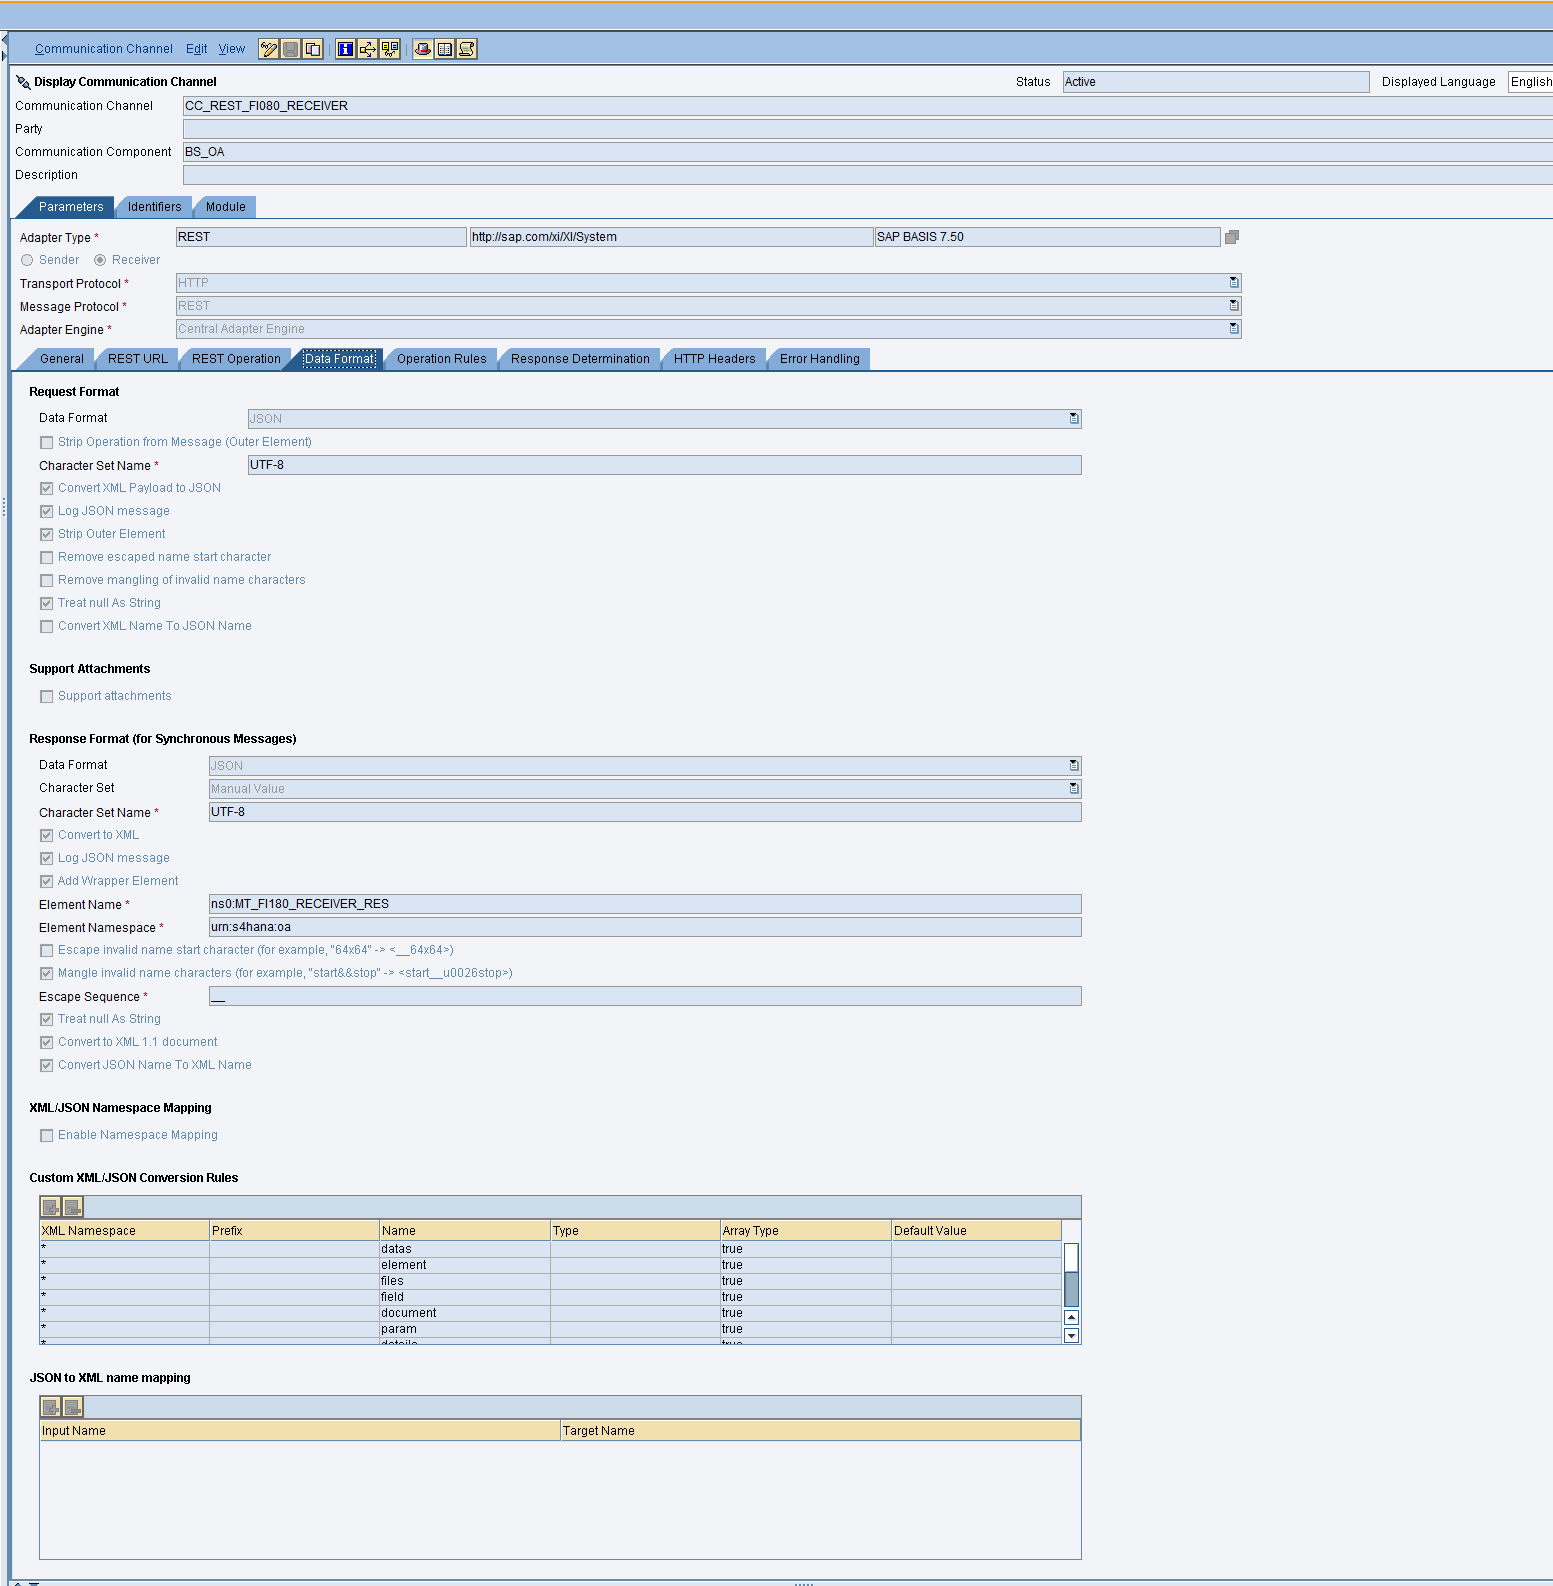

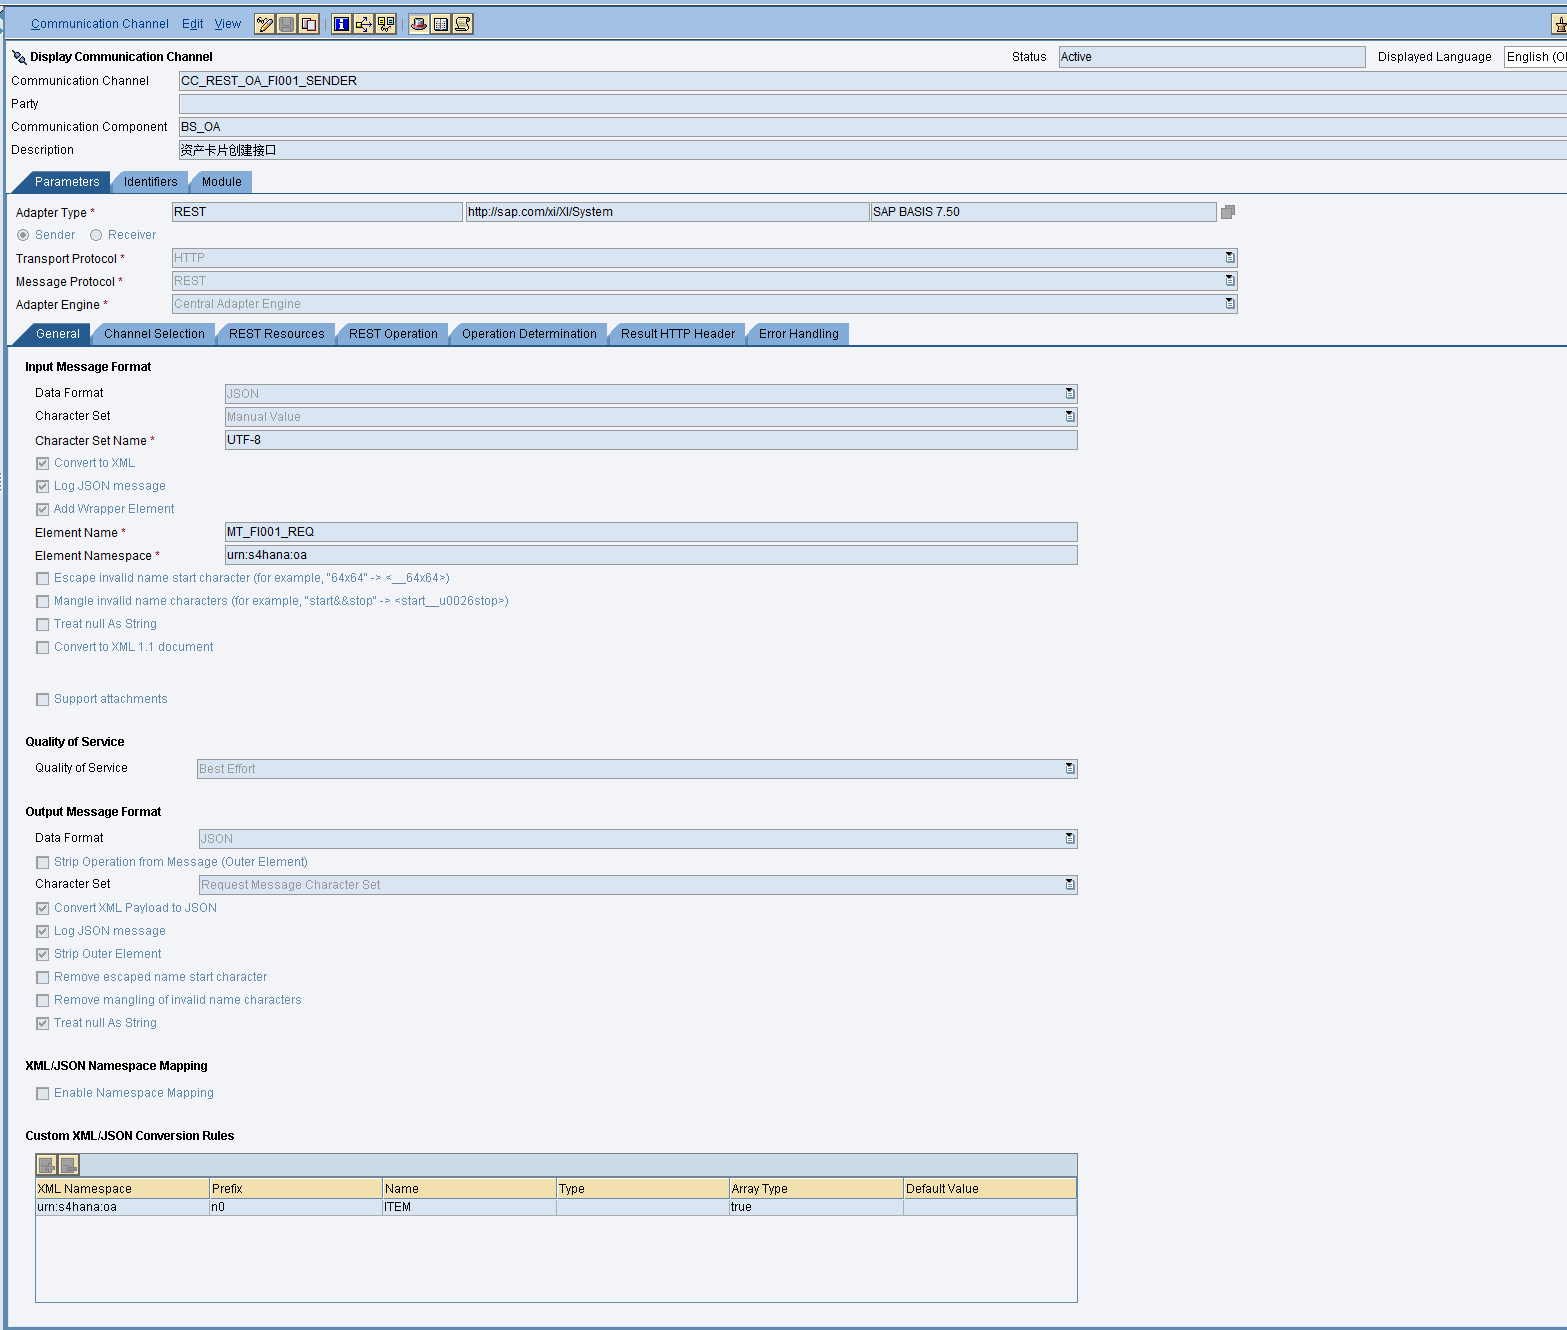

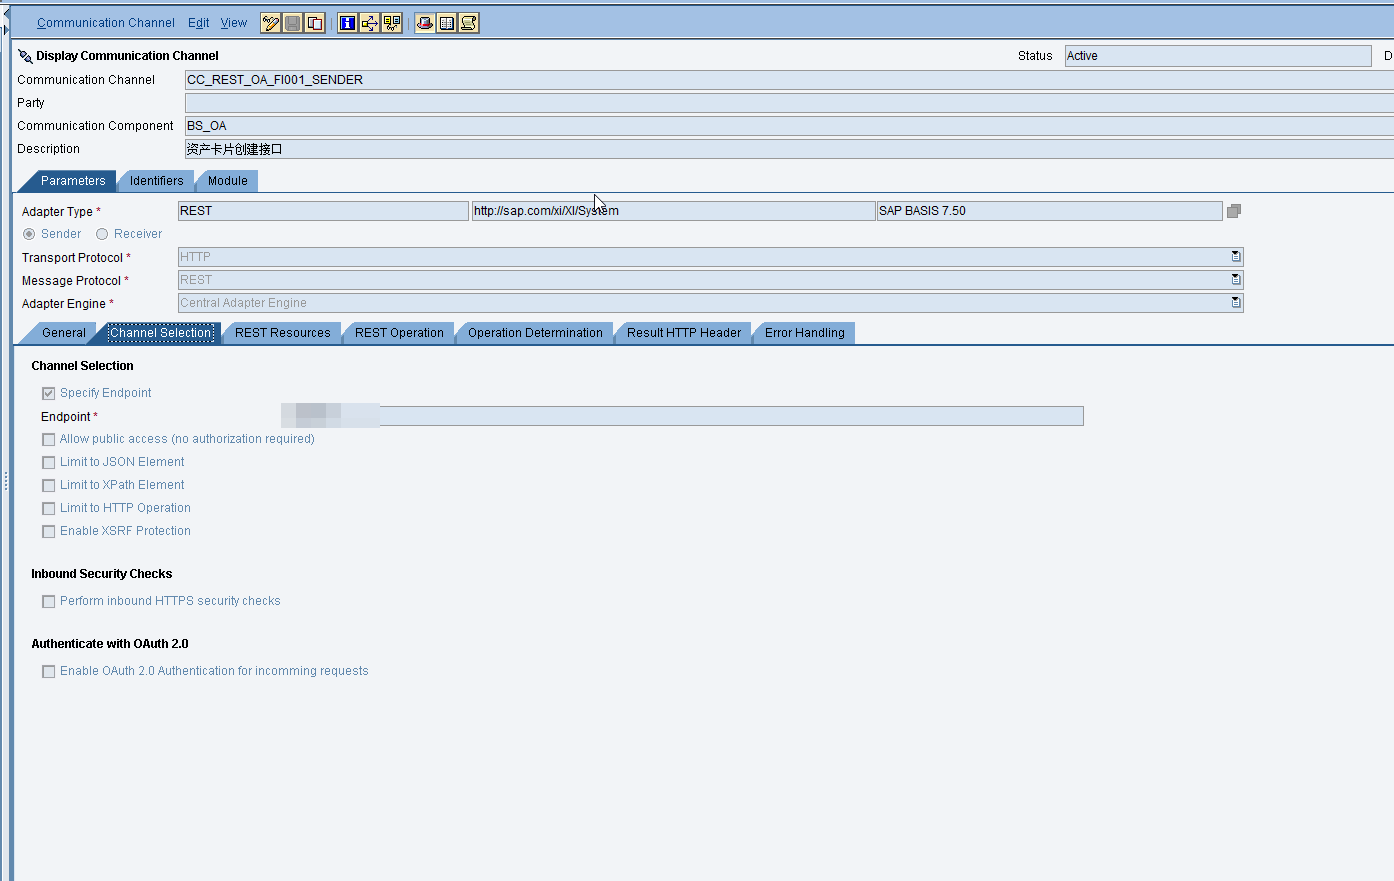

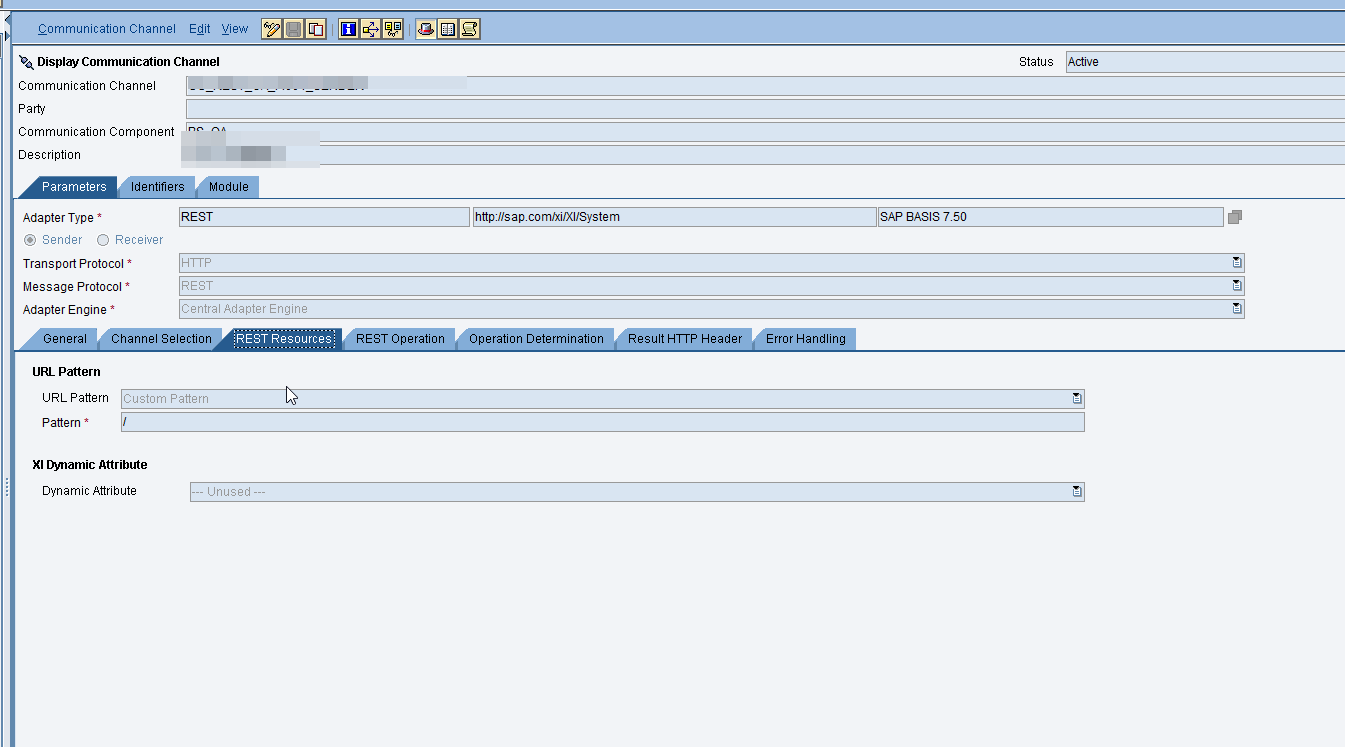

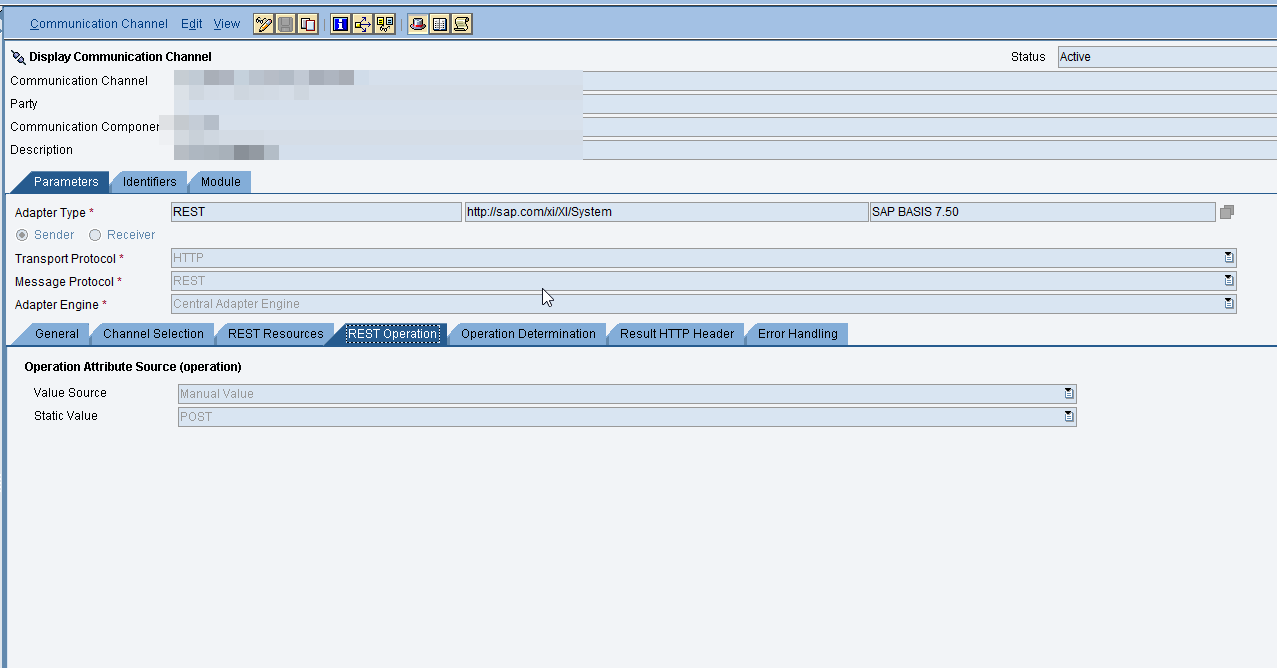